In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from sklearn.metrics import classification_report

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import sys
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'

train_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'
test_file = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_WNV_Dataset_GRID_OP_2017_2018.csv'

data_train = read_data(train_file)
data_test = read_data(test_file)

data_train.reset_index(drop = True, inplace = True)
data_test.reset_index(drop = True, inplace = True)

print(data_train.shape)
print(data_test.shape)

(664560, 92)
(105984, 91)


In [2]:
data_train.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [3]:
data_test.head()

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
0,0,EL52,EL524,εδεσσας,2017,1,21.76334,40.79806,0.320460,-0.094893,-0.298378,0.094893,0.308388,-0.097008,-0.289511,0.097008,0.016442,0.028326,0.014441,0.028326,5.750645,3.481613,9.942143,16.799032,21.175333,-0.806129,-2.502258,-3.708571,3.876452,5.038000,2.472258,0.489677,3.116786,10.337742,13.106667,-8.37,11.27,0.607075,3.273430,3.273430,3.467208,115.230505,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.000000,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.00000,1.000000,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
1,1,EL52,EL524,εδεσσας,2017,1,21.76334,40.81603,0.362838,-0.086531,-0.366083,0.086531,0.343428,-0.123457,-0.360012,0.123457,0.011866,0.023273,0.022091,0.023273,6.090645,3.270000,10.827143,18.784194,20.806667,-2.492581,-4.995806,-2.710714,2.820968,3.737333,1.799032,-0.862903,4.058214,10.802581,12.272000,-9.81,12.89,0.555982,0.335393,0.335393,1.428161,112.902887,12.750000,24.333333,56.589147,711.113084,34.0,-9.0,43.0,17.000000,6.833333,21.166667,3.833333,1444.0,264.0,17.0,60.161585,517.0,223.0,247.0,242.0,22,20,20,9,9,4,4,4,2463.154314,575.852541,20,187.414374,897.449167,168.372446,0.00000,3.327142,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
2,2,EL52,EL524,εδεσσας,2017,1,21.76334,40.83400,0.296266,-0.045876,-0.334076,0.045876,0.377195,-0.055990,-0.383619,0.055990,0.043642,0.041990,0.027121,0.041990,8.828710,0.974516,7.206429,18.857097,19.363333,-2.548065,-10.376452,-7.642857,0.913871,3.106667,3.140323,-4.700968,-0.218214,9.885484,11.235000,-11.17,14.19,0.555982,0.335393,0.335393,1.428161,112.902887,12.083333,23.333333,54.263566,666.685606,32.0,-11.0,43.0,15.000000,6.833333,20.166667,3.333333,1444.0,264.0,17.0,60.161585,517.0,223.0,247.0,249.0,31,30,30,10,10,1,6,6,3829.512564,2424.332192,15,132.525146,1204.950661,166.684023,0.00000,12.023969,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
3,3,EL52,EL524,εδεσσας,2017,1,21.76334,40.85196,0.290723,-0.121547,-0.298428,0.121547,0.316915,-0.107043,-0.342255,0.107043,0.049027,0.033765,0.057875,0.033765,6.206774,-1.356452,6.012143,16.895161,16.504000,-0.996452,-10.048065,-5.824286,2.487419,3.346000,2.605161,-5.702258,0.093929,9.691290,9.925000,-5.53,12.27,0.555982,0.335393,0.335393,1.428161,112.902887,11.166667,20.333333,52.136752,581.273419,28.0,-11.0,39.0,13.666667,6.666667,18.000000,3.666667,1444.0,264.0,17.0,60.161585,517.0,223.0,247.0,249.0,31,30,30,10,10,1,6,6,5531.908352,2401.264849,11,137.533043,1333.936554,135.526189,0.00000,1.000000,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
4,4,EL52,EL524,εδεσσας,2017,1,21.78676,40.79806,-0.167772,0.413822,0.334197,-0.413822,-0.082935,0.262008,0.216282,-0.262008,0.187479,0.242964,0.255348,0.242964,7.427419,4.591935,8.352857,14.280323,19.162000,4.407419,1.079677,1.731429,5.197097,9.

In [4]:
len(data_train.cell_code.unique())

4260

In [5]:
len(data_test.cell_number.unique())

4416

In [6]:
data_train = encode_cyclical(data_train, 'month', 12)
data_test = encode_cyclical(data_test, 'month', 12)

In [7]:
data_train.cases.sum()

1364

In [8]:
# data_test.cases.sum()

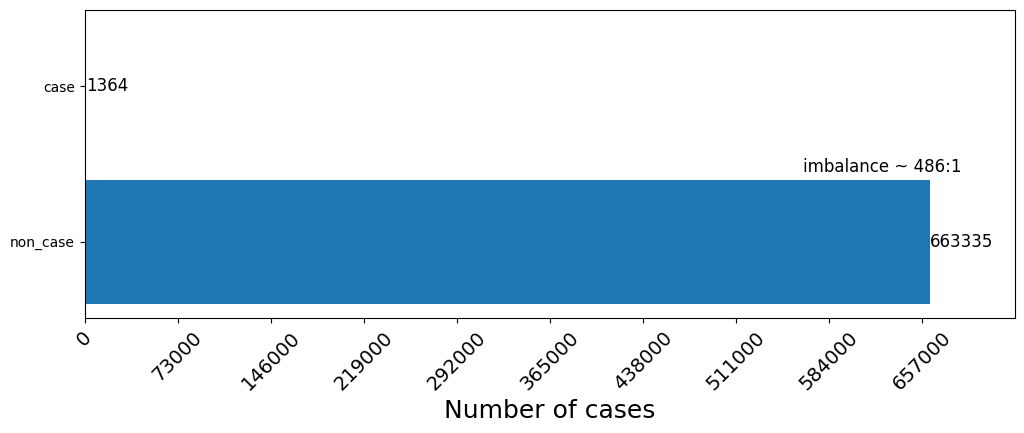

In [9]:
plot_imbalance(data_train, target_column='cases')

In [10]:
# plot_imbalance(data_test, target_column='cases')

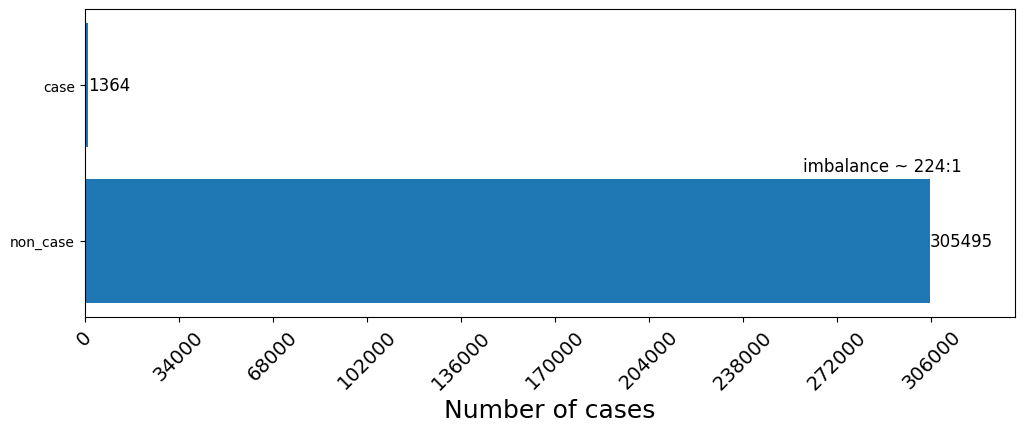

In [11]:
data_train = data_train.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [12]:
data_test = data_test.query('month >= 5 & month <= 10')
data_test.reset_index(drop=True, inplace=True)

# plot_imbalance(data_test, target_column='cases')

In [13]:
test_nuts3 = data_test.nuts3_id.unique()
test_years = data_test.year.unique()

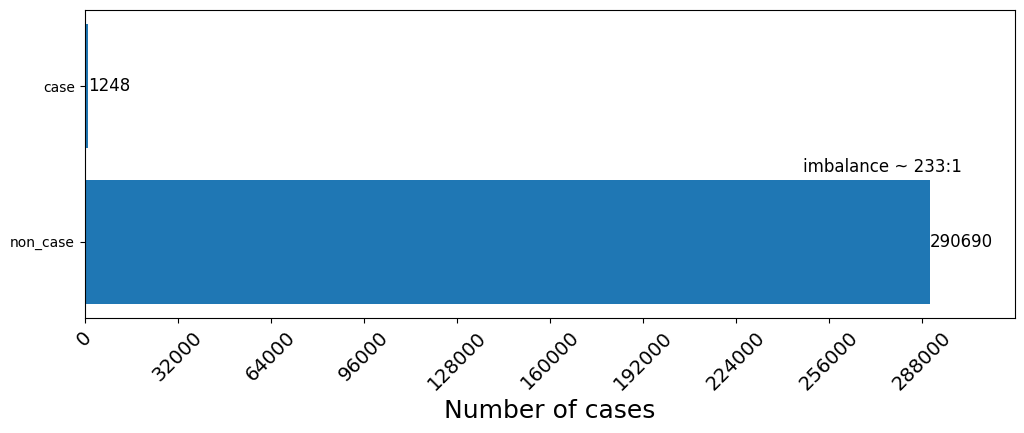

In [14]:
data_train = data_train.query('not (year in @test_years and nuts3_id in @test_nuts3)')
# dataset = dataset.query('month >= 5')
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [15]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

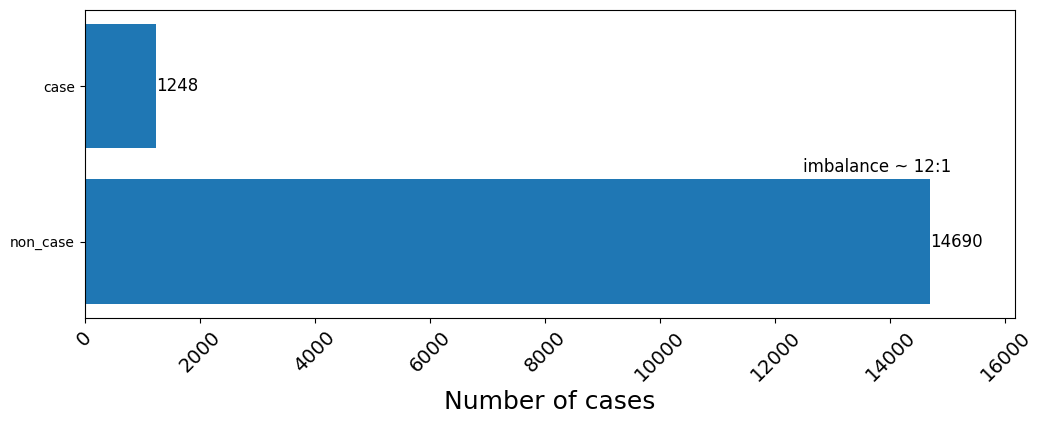

In [16]:
rows_to_remove = data_train.query('cases == 0').sample(n=276000, random_state=0).index
# rows_to_remove = data_train.query('cases == 0').sample(n=150000, random_state=0).index

data_train.drop(rows_to_remove, inplace=True)
data_train.reset_index(drop=True, inplace=True)

plot_imbalance(data_train, target_column='cases')

In [17]:
data_train.shape

(15804, 94)

In [18]:
data_train.cases.sum()

1248

In [19]:
dsc = dataframe_describe(data_train, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,1295,262,1557,4.94%
1,2011,1265,100,1365,12.65%
2,2012,1275,157,1432,8.12%
3,2013,1300,85,1385,15.29%
4,2014,1239,15,1254,82.60%
5,2015,1336,0,1336,inf%
6,2016,1298,0,1298,inf%
7,2017,842,42,884,20.05%
8,2018,910,180,1090,5.06%
9,2019,1265,218,1483,5.80%


In [20]:
features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [21]:
data_train = convert_multiple_cases(data_train, target_col='cases')
data_train.reset_index(inplace = True, drop = True)

sum_negatives = data_train['cases'].value_counts().get(0)
sum_positives = data_train['cases'].value_counts().get(1)

params = {
    "seed": 0,
    "objective": "binary:logistic",
    "device": "gpu", 
    "eval_metric": "logloss",
    "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
    "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
    "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
    "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
    "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
    "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
    "scale_pos_weight": sum_negatives/sum_positives, 
}


X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train['cases']

print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
    
model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

Training set 0/1 Ratio: 11.77
Weight: 11.77


In [22]:
data_test_2017_may = data_test.query('month == 5 & year <= 2017').reset_index(drop=True)
data_test_2017_jun = data_test.query('month == 6 & year <= 2017').reset_index(drop=True)
data_test_2017_jul = data_test.query('month == 7 & year <= 2017').reset_index(drop=True)
data_test_2017_aug = data_test.query('month == 8 & year <= 2017').reset_index(drop=True)
data_test_2017_sep = data_test.query('month == 9 & year <= 2017').reset_index(drop=True)
data_test_2017_oct = data_test.query('month == 10 & year <= 2017').reset_index(drop=True)

In [23]:
data_test_2018_may = data_test.query('month == 5 & year <= 2018').reset_index(drop=True)
data_test_2018_jun = data_test.query('month == 6 & year <= 2018').reset_index(drop=True)
data_test_2018_jul = data_test.query('month == 7 & year <= 2018').reset_index(drop=True)
data_test_2018_aug = data_test.query('month == 8 & year <= 2018').reset_index(drop=True)
data_test_2018_sep = data_test.query('month == 9 & year <= 2018').reset_index(drop=True)
data_test_2018_oct = data_test.query('month == 10 & year <= 2018').reset_index(drop=True)

### Results 2017 ###

In [24]:
X_test = data_test_2017_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_may['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2017_may = pd.concat([data_test_2017_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [25]:
X_test = data_test_2017_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jun['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2017_jun = pd.concat([data_test_2017_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [26]:
X_test = data_test_2017_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_jul['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2017_jul = pd.concat([data_test_2017_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [27]:
X_test = data_test_2017_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_aug['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2017_aug = pd.concat([data_test_2017_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [28]:
X_test = data_test_2017_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_sep['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2017_sep = pd.concat([data_test_2017_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [29]:
X_test = data_test_2017_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2017_oct['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2017_oct = pd.concat([data_test_2017_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

### Results 2018 ###

In [30]:
X_test = data_test_2018_may.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2018_may['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2018_may = pd.concat([data_test_2018_may.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [31]:
X_test = data_test_2018_jun.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2018_jun['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2018_jun = pd.concat([data_test_2018_jun.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [32]:
X_test = data_test_2018_jul.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2018_jul['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2018_jul = pd.concat([data_test_2018_jul.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [33]:
X_test = data_test_2018_aug.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2018_aug['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2018_aug = pd.concat([data_test_2018_aug.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [34]:
X_test = data_test_2018_sep.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2018_sep['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2018_sep = pd.concat([data_test_2018_sep.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [35]:
X_test = data_test_2018_oct.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cell_number'])
# y_test = data_test_2018_oct['cases']

X_test_scaled = scaler.transform(X_test)
X_test_imputed = imputer.transform(X_test_scaled)
    
y_test_prob = trained_model.predict_proba(X_test_imputed)[:, 1].tolist()

results_2018_oct = pd.concat([data_test_2018_oct.iloc[:, :8], pd.Series(y_test_prob, name='score')], axis=1)

In [36]:
results_2017_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
1005,1005,EL52,EL524,πελλας,2017,5,22.39575,40.76213,0.085947
1118,1118,EL52,EL521,αλεξανδρειας,2017,5,22.44259,40.67230,0.080226
1180,1180,EL52,EL521,αλεξανδρειας,2017,5,22.46601,40.70823,0.076873
779,779,EL52,EL521,ναουσας,2017,5,22.30206,40.63636,0.075243
1507,1507,EL52,EL522,χαλκηδονος,2017,5,22.60655,40.65433,0.066043


In [37]:
results_2017_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3168,3168,EL52,EL527,πολυγυρου,2017,6,23.40292,40.31296,0.090774
3235,3235,EL52,EL527,πολυγυρου,2017,6,23.42634,40.31296,0.085837
2966,2966,EL52,EL527,νεας προποντιδας,2017,6,23.33265,40.25906,0.079950
2837,2837,EL52,EL527,νεας προποντιδας,2017,6,23.28580,40.27703,0.078441
3100,3100,EL52,EL527,πολυγυρου,2017,6,23.37949,40.33093,0.067996


In [38]:
results_2017_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
782,782,EL52,EL524,πελλας,2017,7,22.30206,40.69026,0.922101
738,738,EL52,EL524,πελλας,2017,7,22.27863,40.85196,0.914120
3410,3410,EL52,EL526,σερρων,2017,7,23.47318,41.10350,0.908621
555,555,EL52,EL521,βεροιας,2017,7,22.20837,40.52856,0.905808
1537,1537,EL52,EL521,αλεξανδρειας,2017,7,22.62997,40.54653,0.889587


In [39]:
results_2017_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
470,470,EL52,EL524,σκυδρας,2017,8,22.16152,40.78010,0.941004
947,947,EL52,EL524,πελλας,2017,8,22.37232,40.79806,0.936903
555,555,EL52,EL521,βεροιας,2017,8,22.20837,40.52856,0.933945
438,438,EL52,EL524,αλμωπιας,2017,8,22.13810,40.97773,0.931710
734,734,EL52,EL524,πελλας,2017,8,22.27863,40.78010,0.929712


In [40]:
results_2017_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
3604,3604,EL52,EL526,σερρων,2017,9,23.54345,41.08553,0.916426
2889,2889,EL52,EL526,ηρακλειας,2017,9,23.28580,41.21130,0.868576
3977,3977,EL52,EL526,βισαλτιας,2017,9,23.68399,40.88790,0.864051
3538,3538,EL52,EL526,σερρων,2017,9,23.52003,41.08553,0.853788
3410,3410,EL52,EL526,σερρων,2017,9,23.47318,41.10350,0.852234


In [41]:
results_2017_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2537,2537,EL52,EL526,σιντικης,2017,10,23.14527,41.22926,0.697471
2538,2538,EL52,EL526,σιντικης,2017,10,23.14527,41.24723,0.637430
3977,3977,EL52,EL526,βισαλτιας,2017,10,23.68399,40.88790,0.499344
3410,3410,EL52,EL526,σερρων,2017,10,23.47318,41.10350,0.444717
3604,3604,EL52,EL526,σερρων,2017,10,23.54345,41.08553,0.441532


In [42]:
results_2018_may.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
5482,1066,EL52,EL524,πελλας,2018,5,22.41917,40.79806,0.159718
5419,1003,EL52,EL524,πελλας,2018,5,22.39575,40.72620,0.098812
1005,1005,EL52,EL524,πελλας,2017,5,22.39575,40.76213,0.085947
1118,1118,EL52,EL521,αλεξανδρειας,2017,5,22.44259,40.67230,0.080226
1180,1180,EL52,EL521,αλεξανδρειας,2017,5,22.46601,40.70823,0.076873


In [43]:
results_2018_jun.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
5781,1365,EL52,EL521,αλεξανδρειας,2018,6,22.53628,40.65433,0.549179
5360,944,EL52,EL524,πελλας,2018,6,22.37232,40.74416,0.444987
5596,1180,EL52,EL521,αλεξανδρειας,2018,6,22.46601,40.70823,0.406756
5915,1499,EL52,EL525,πυδνας κολινδρου,2018,6,22.60655,40.51060,0.404124
5787,1371,EL52,EL524,πελλας,2018,6,22.53628,40.76213,0.355046


In [44]:
results_2018_jul.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
5309,893,EL52,EL524,πελλας,2018,7,22.34890,40.81603,0.962465
4737,321,EL52,EL524,αλμωπιας,2018,7,22.06783,41.03163,0.948213
5772,1356,EL52,EL525,πυδνας κολινδρου,2018,7,22.53628,40.49263,0.947941
782,782,EL52,EL524,πελλας,2017,7,22.30206,40.69026,0.922101
5153,737,EL52,EL524,πελλας,2018,7,22.27863,40.83400,0.916939


In [45]:
results_2018_aug.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
5309,893,EL52,EL524,πελλας,2018,8,22.34890,40.81603,0.986219
5422,1006,EL52,EL524,πελλας,2018,8,22.39575,40.78010,0.975007
5482,1066,EL52,EL524,πελλας,2018,8,22.41917,40.79806,0.968102
5198,782,EL52,EL524,πελλας,2018,8,22.30206,40.69026,0.966784
5100,684,EL52,EL524,πελλας,2018,8,22.25521,40.85196,0.966541


In [46]:
results_2018_sep.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
5309,893,EL52,EL524,πελλας,2018,9,22.34890,40.81603,0.984372
5772,1356,EL52,EL525,πυδνας κολινδρου,2018,9,22.53628,40.49263,0.970999
5198,782,EL52,EL524,πελλας,2018,9,22.30206,40.69026,0.968545
5482,1066,EL52,EL524,πελλας,2018,9,22.41917,40.79806,0.960626
5364,948,EL52,EL524,πελλας,2018,9,22.37232,40.81603,0.950786


In [47]:
results_2018_oct.sort_values(by='score', ascending=False).head(5)

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
2537,2537,EL52,EL526,σιντικης,2017,10,23.14527,41.22926,0.697471
6680,2264,EL52,EL527,νεας προποντιδας,2018,10,23.05158,40.34890,0.669739
5695,1279,EL52,EL525,κατερινης,2018,10,22.51286,40.25906,0.654441
2538,2538,EL52,EL526,σιντικης,2017,10,23.14527,41.24723,0.637430
8086,3670,EL52,EL526,σερρων,2018,10,23.56687,41.08553,0.614096


In [48]:
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"
cm_grid = gpd.read_file(r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\CMacedonia\GR_CMacedonia_GRID.shp',  encoding='utf-8')
greece_nuts2_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding='utf8')
greece_lau1 = gpd.read_file(f"{folder_path}/el_lau1.shp",  encoding='utf8')

In [49]:
cm_grid.head()

,cell_numbe,NUTS2_ID,x,y,geometry
0,0,EL52,21.76334,40.79806,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,EL52,21.76334,40.81603,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,EL52,21.76334,40.83400,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,EL52,21.76334,40.85196,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,EL52,21.78676,40.79806,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [50]:
greece_nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [51]:
greece_lau1.head()

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [52]:
cm_grid = cm_grid.to_crs(epsg=4326)
cm_grid.drop(columns=['NUTS2_ID', 'x', 'y'], inplace=True)
cm_grid = cm_grid.set_axis(['cell_number', 'geometry'], axis=1)
print(f'greece_index CRS: {cm_grid.crs}')

greece_index CRS: EPSG:4326


In [53]:
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)
greece_nuts2_gdf.drop(columns=['CNTR_CODE', 'NAME_LATN', 'CNTR_NAME'], inplace=True)
greece_nuts2_gdf = greece_nuts2_gdf[greece_nuts2_gdf['NUTS_ID'] == 'EL52']
greece_nuts2_gdf.reset_index(drop=True, inplace=True)
print(f'greece_nuts2 CRS: {greece_nuts2_gdf.crs}')

greece_nuts2 CRS: EPSG:4326


In [54]:
greece_lau1 = greece_lau1.to_crs(epsg=4326)
greece_lau1.drop(columns=['KWD_YPES'], inplace=True)
greece_lau1_outer = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='overlaps')
greece_lau1_inner = gpd.sjoin(greece_lau1, greece_nuts2_gdf, op='within')
greece_lau1 = pd.concat([greece_lau1_outer, greece_lau1_inner], axis=0)
greece_lau1.drop(columns=['index_right','NUTS_ID','NUTS_NAME'], inplace=True)

wrong_list = ['Φλώρινας' ,'Αμυνταίου', 'Εορδαίας', 'Κοζάνης', 'Σερβίων - Βελβεντού', 'Ελασσόνας', 'Τεμπών', 'Κάτω Νευροκοπίου',
 'Προσοτσάνης', 'Δοξάτου', 'Παγγαίου', 'Άθως']

greece_lau1 = greece_lau1[~greece_lau1['NAME'].isin(wrong_list)].copy()
greece_lau1.reset_index(drop = True, inplace = True)

In [55]:
cm_grid.head()

,cell_number,geometry
0,0,"POLYGON ((21.77505 40.78908, 21.75163 40.78908..."
1,1,"POLYGON ((21.77505 40.80705, 21.75163 40.80705..."
2,2,"POLYGON ((21.77505 40.82501, 21.75163 40.82501..."
3,3,"POLYGON ((21.77505 40.84298, 21.75163 40.84298..."
4,4,"POLYGON ((21.79847 40.78908, 21.77505 40.78908..."


In [56]:
greece_nuts2_gdf.head()

,NUTS_ID,NUTS_NAME,geometry
0,EL52,Κεντρική Μακεδονία,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [57]:
greece_lau1.head()



,NAME,geometry
0,Έδεσσας,"POLYGON ((21.99535 40.90380, 21.99562 40.90344..."
1,Αλεξάνδρειας,"MULTIPOLYGON (((22.66199 40.52431, 22.66194 40..."
2,Αλμωπίας,"POLYGON ((22.22498 41.16444, 22.22529 41.16444..."
3,Αμπελοκήπων - Μενεμένης,"POLYGON ((22.87764 40.66601, 22.87775 40.66573..."
4,Αμφίπολης,"POLYGON ((24.04143 41.04942, 24.04322 41.04930..."


In [58]:
results_2017_may

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,score
0,0,EL52,EL524,εδεσσας,2017,5,21.76334,40.79806,0.000125
1,1,EL52,EL524,εδεσσας,2017,5,21.76334,40.81603,0.000267
2,2,EL52,EL524,εδεσσας,2017,5,21.76334,40.83400,0.000042
3,3,EL52,EL524,εδεσσας,2017,5,21.76334,40.85196,0.000046
4,4,EL52,EL524,εδεσσας,2017,5,21.78676,40.79806,0.000149
...,...,...,...,...,...,...,...,...,...
4411,4411,EL52,EL526,αμφιπολης,2017,5,24.05875,40.99570,0.000565
4412,4412,EL52,EL526,αμφιπολης,2017,5,24.05875,41.01366,0.003024
4413,4413,EL52,EL526,αμφιπολης,2017,5,24.08217,40.95976,0.000190
4414,4414,EL52,EL526,αμφιπολης,2017,5,24.08217,40.97773,0.000119


In [59]:
results_2017_may = pd.merge(results_2017_may, cm_grid, on='cell_number', how='left')
results_2017_may = gpd.GeoDataFrame(results_2017_may, geometry='geometry')

results_2017_jun = pd.merge(results_2017_jun, cm_grid, on='cell_number', how='left')
results_2017_jun = gpd.GeoDataFrame(results_2017_jun, geometry='geometry')

results_2017_jul = pd.merge(results_2017_jul, cm_grid, on='cell_number', how='left')
results_2017_jul = gpd.GeoDataFrame(results_2017_jul, geometry='geometry')

results_2017_aug = pd.merge(results_2017_aug, cm_grid, on='cell_number', how='left')
results_2017_aug = gpd.GeoDataFrame(results_2017_aug, geometry='geometry')

results_2017_sep = pd.merge(results_2017_sep, cm_grid, on='cell_number', how='left')
results_2017_sep = gpd.GeoDataFrame(results_2017_sep, geometry='geometry')

results_2017_oct = pd.merge(results_2017_oct, cm_grid, on='cell_number', how='left')
results_2017_oct = gpd.GeoDataFrame(results_2017_oct, geometry='geometry')

#-------------------------------------------------------------------------------------------

results_2018_may = pd.merge(results_2018_may, cm_grid, on='cell_number', how='left')
results_2018_may = gpd.GeoDataFrame(results_2018_may, geometry='geometry')

results_2018_jun = pd.merge(results_2018_jun, cm_grid, on='cell_number', how='left')
results_2018_jun = gpd.GeoDataFrame(results_2018_jun, geometry='geometry')

results_2018_jul = pd.merge(results_2018_jul, cm_grid, on='cell_number', how='left')
results_2018_jul = gpd.GeoDataFrame(results_2018_jul, geometry='geometry')

results_2018_aug = pd.merge(results_2018_aug, cm_grid, on='cell_number', how='left')
results_2018_aug = gpd.GeoDataFrame(results_2018_aug, geometry='geometry')

results_2018_sep = pd.merge(results_2018_sep, cm_grid, on='cell_number', how='left')
results_2018_sep = gpd.GeoDataFrame(results_2018_sep, geometry='geometry')

results_2018_oct = pd.merge(results_2018_oct, cm_grid, on='cell_number', how='left')
results_2018_oct = gpd.GeoDataFrame(results_2018_oct, geometry='geometry')

In [60]:
float_column = 'score'
geometry_column = 'geometry'
cmap = 'coolwarm'  # Choose your preferred colormap
norm = Normalize(vmin=0, vmax=1)
mapper = ScalarMappable(norm=norm, cmap=cmap)

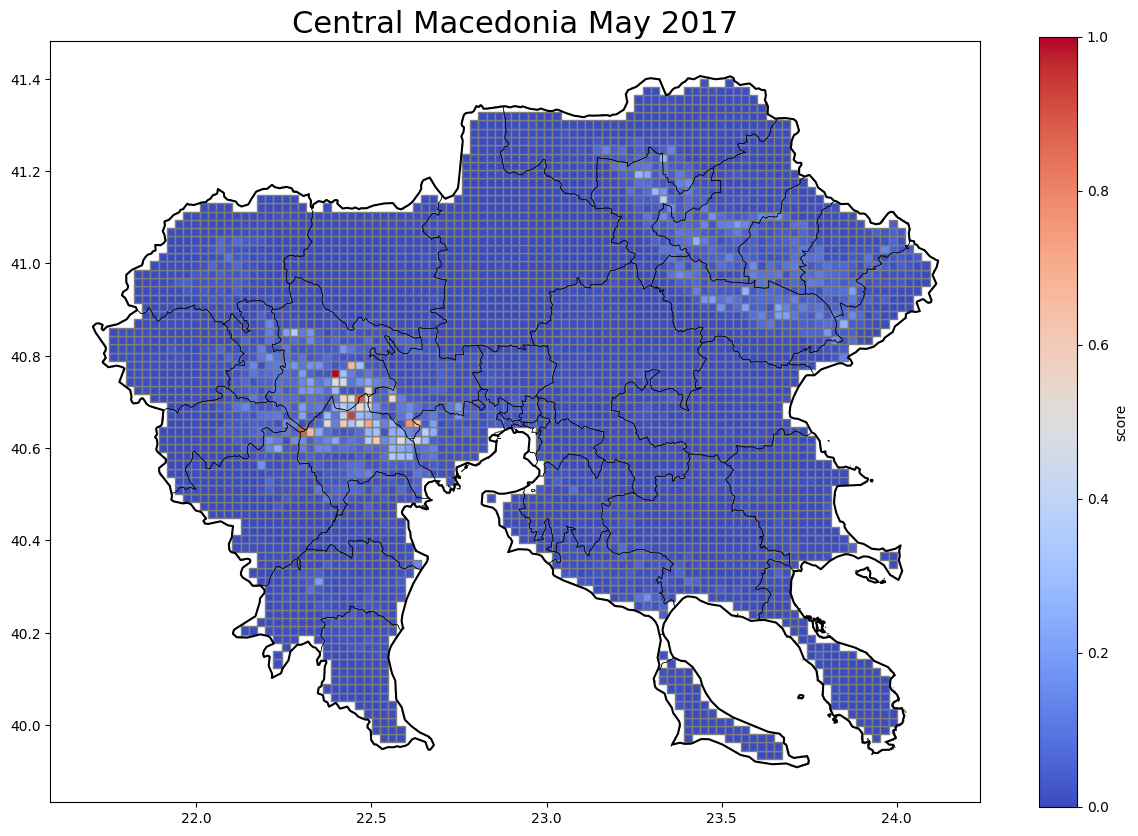

In [68]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column

results_2017_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia May 2017', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

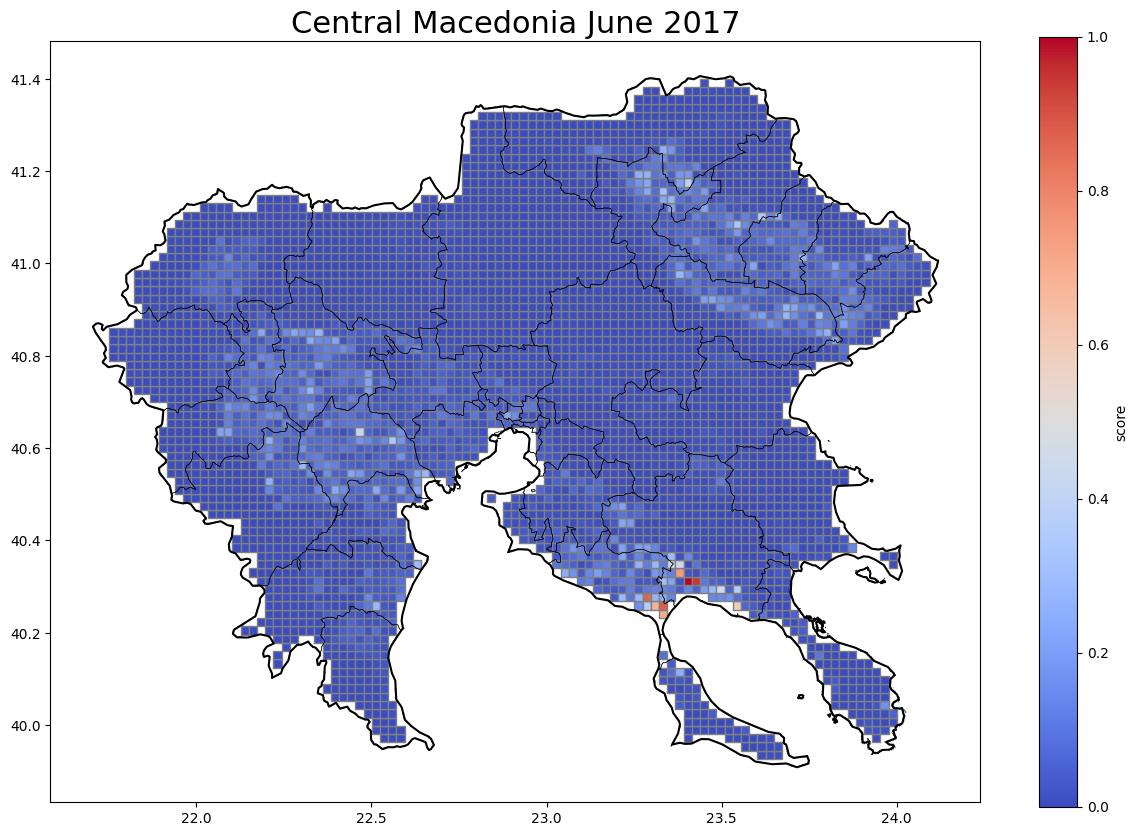

In [69]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2017_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia June 2017', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

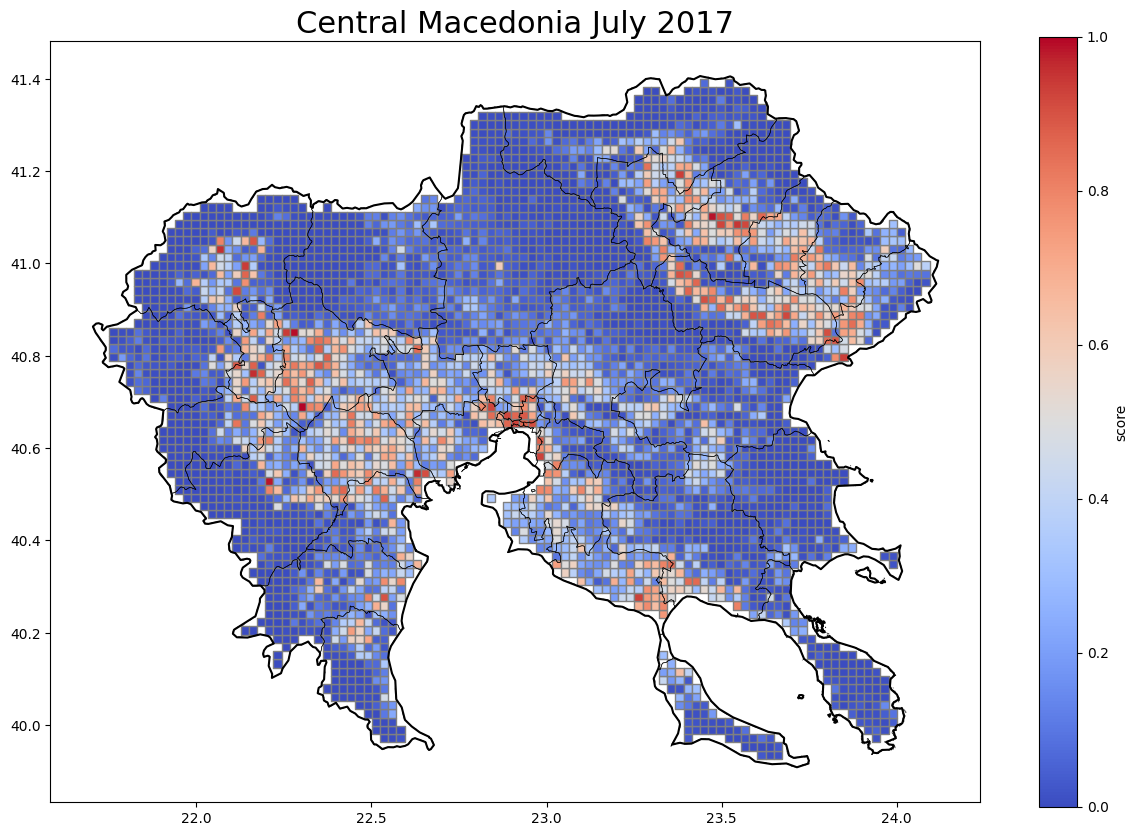

In [70]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2017_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia July 2017', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

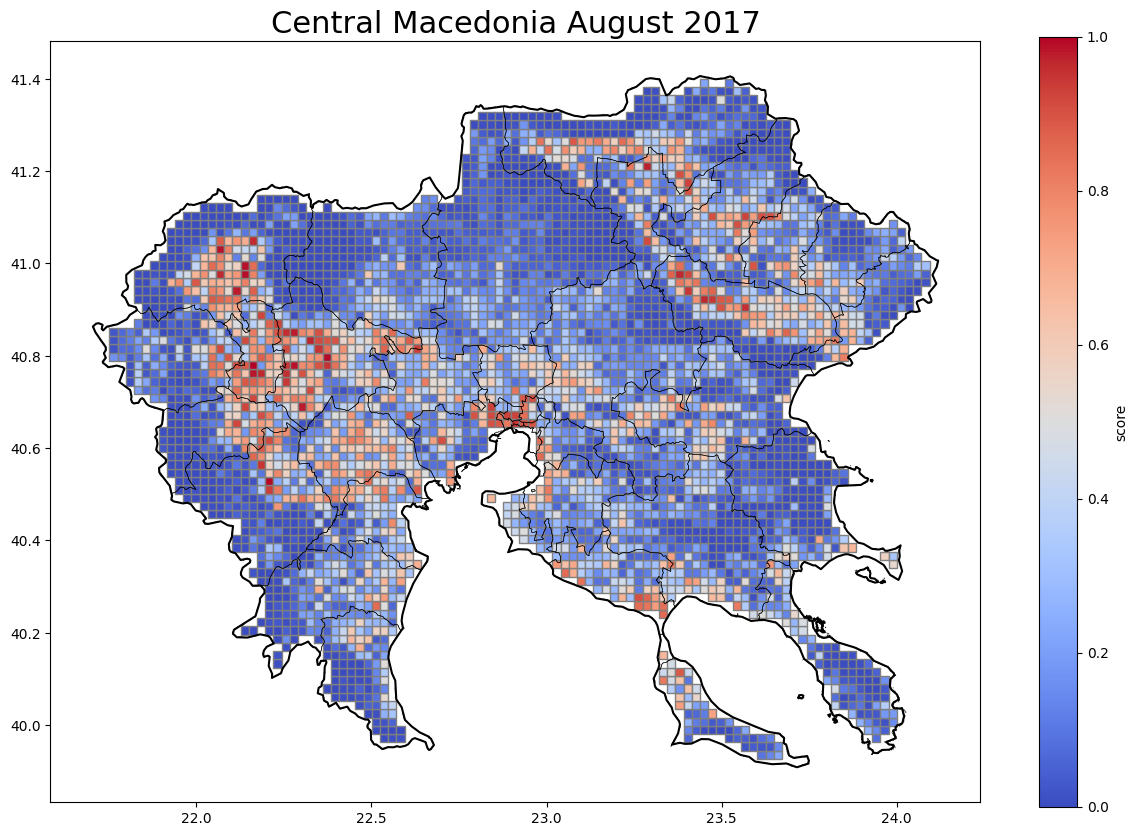

In [71]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2017_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia August 2017', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

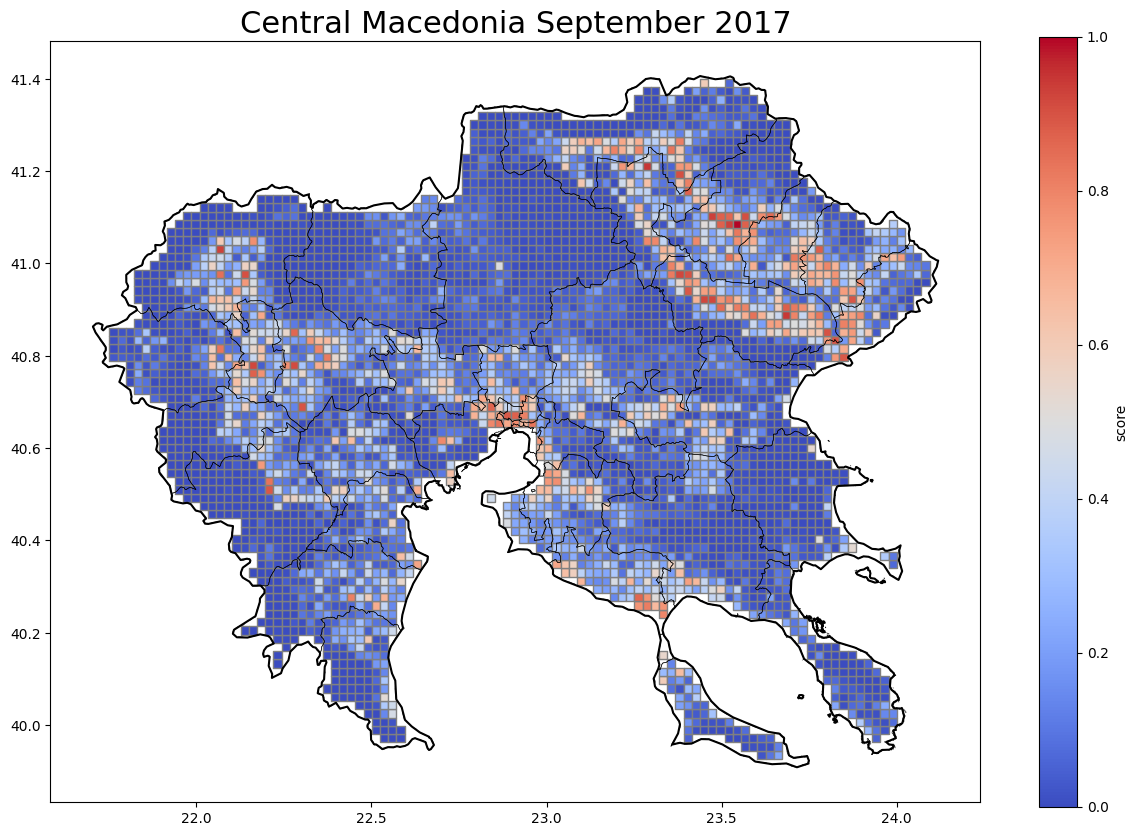

In [72]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2017_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia September 2017', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

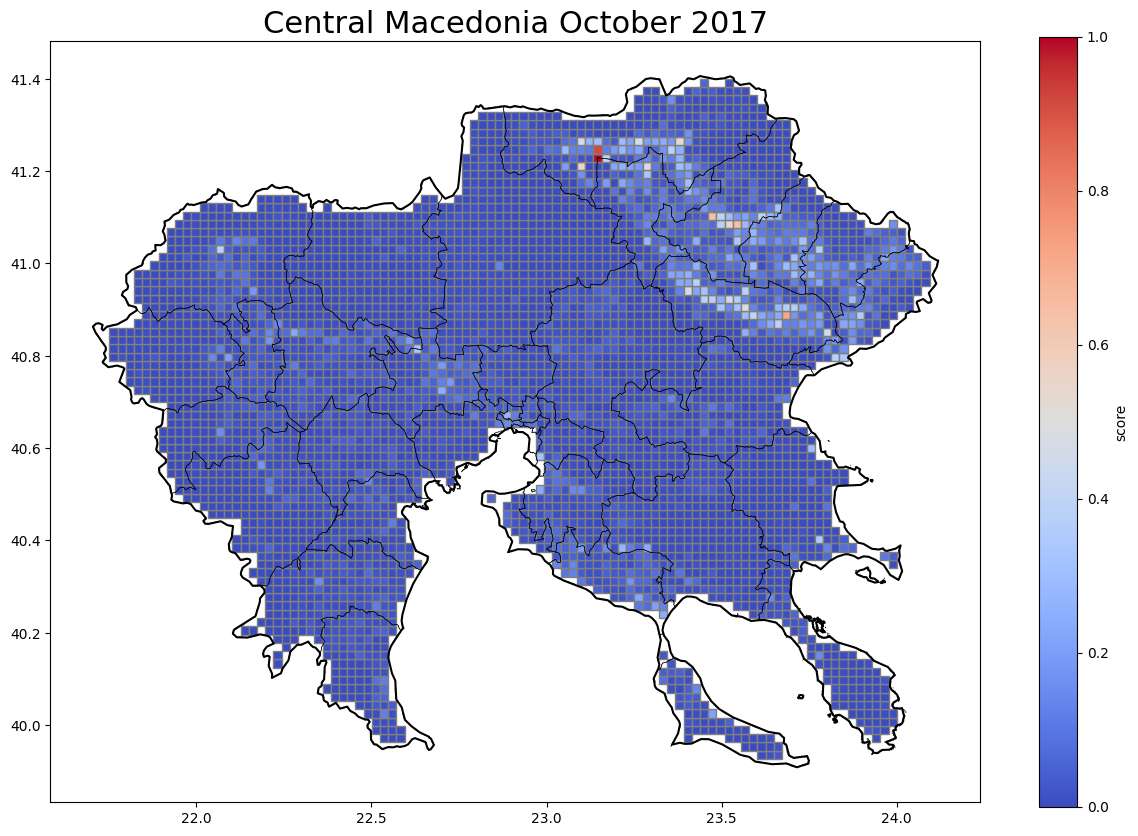

In [73]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2017_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia October 2017', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

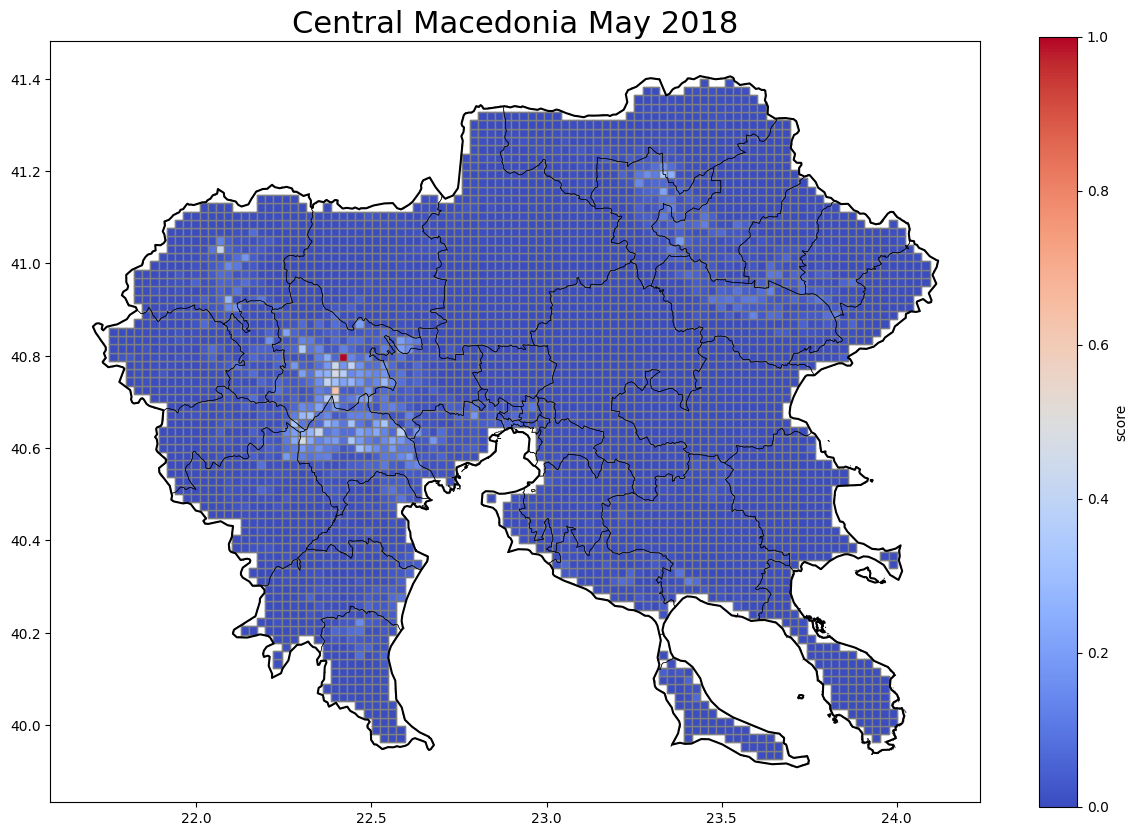

In [74]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2018_may.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia May 2018', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

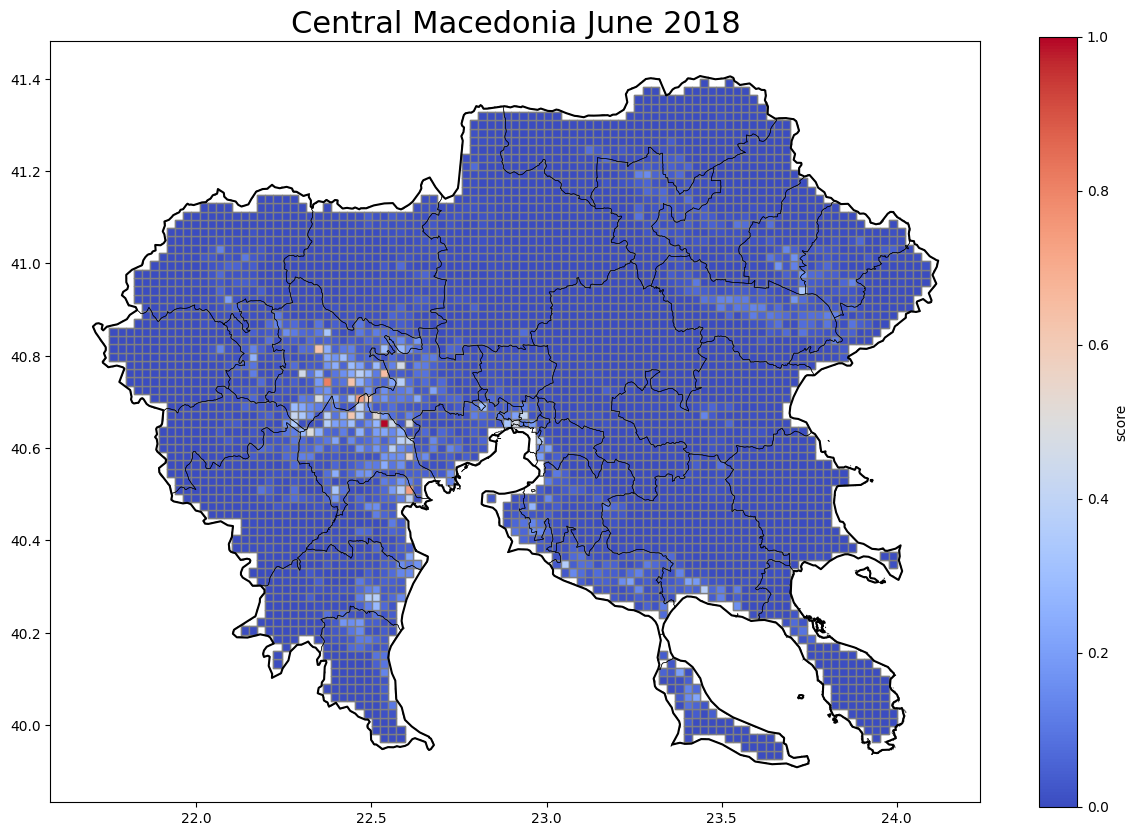

In [75]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2018_jun.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia June 2018', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

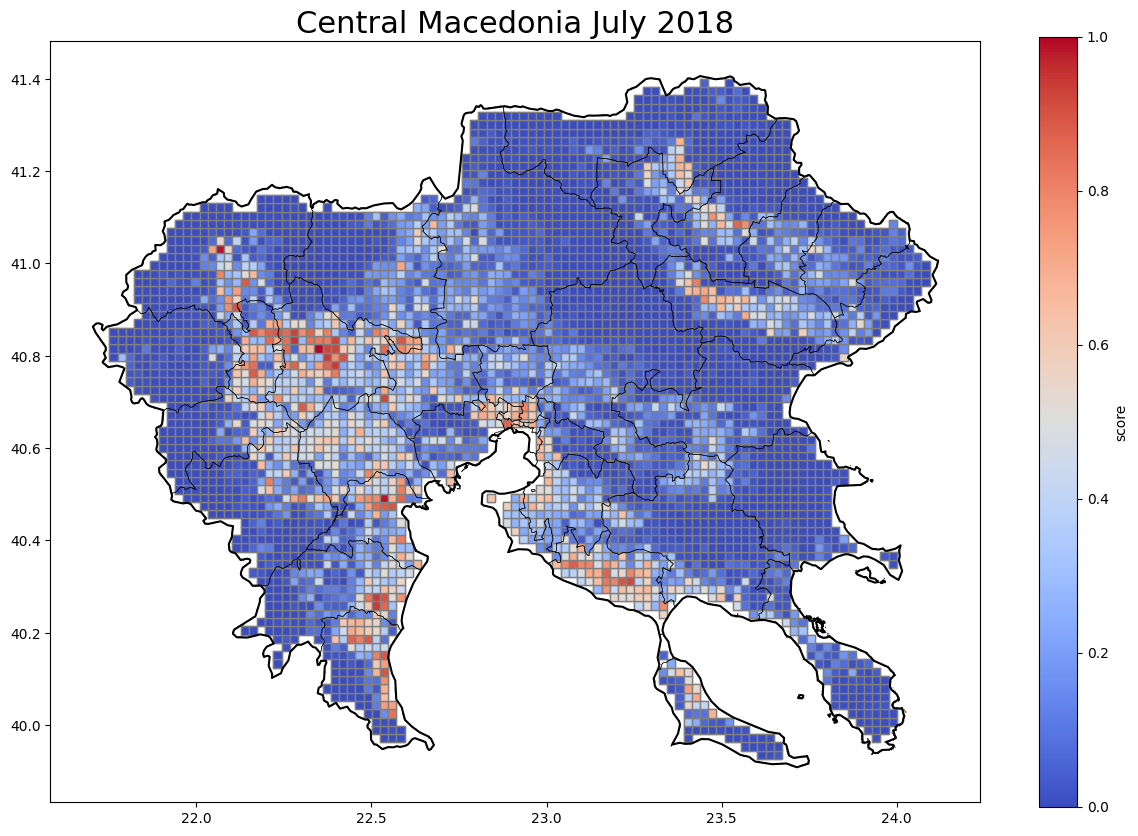

In [76]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2018_jul.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia July 2018', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

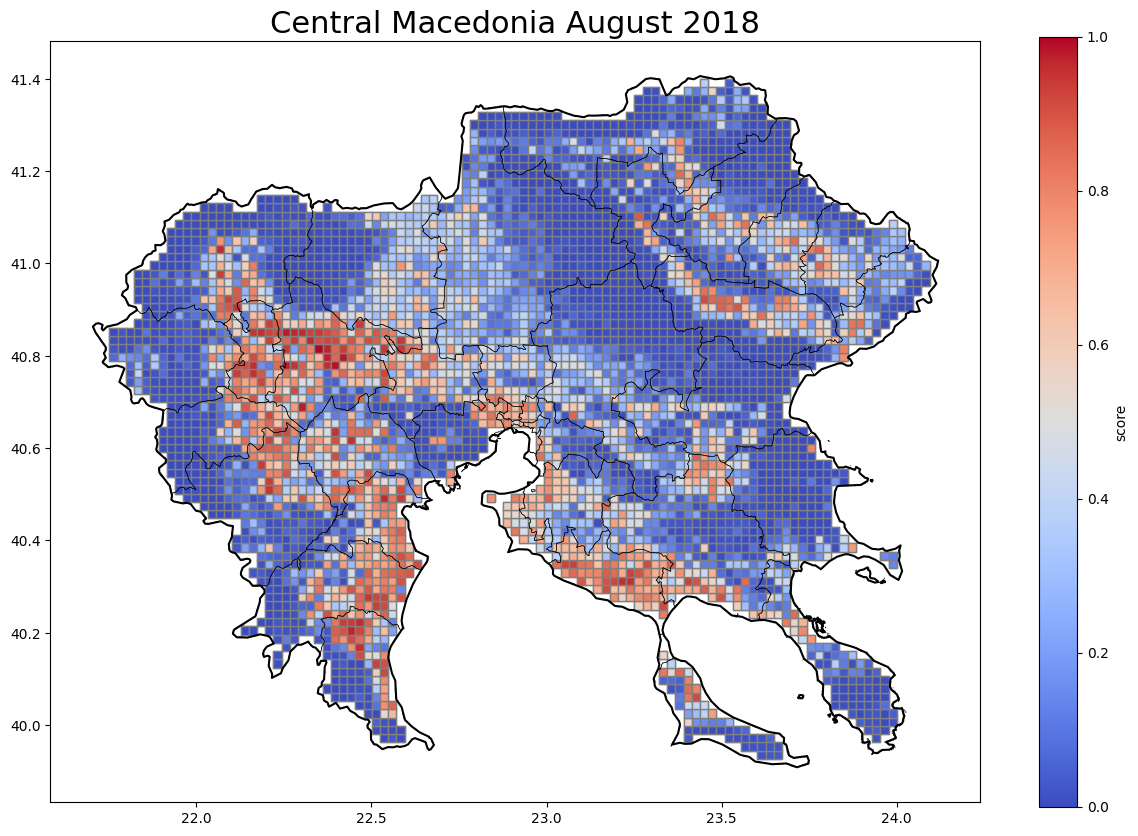

In [77]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2018_aug.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia August 2018', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

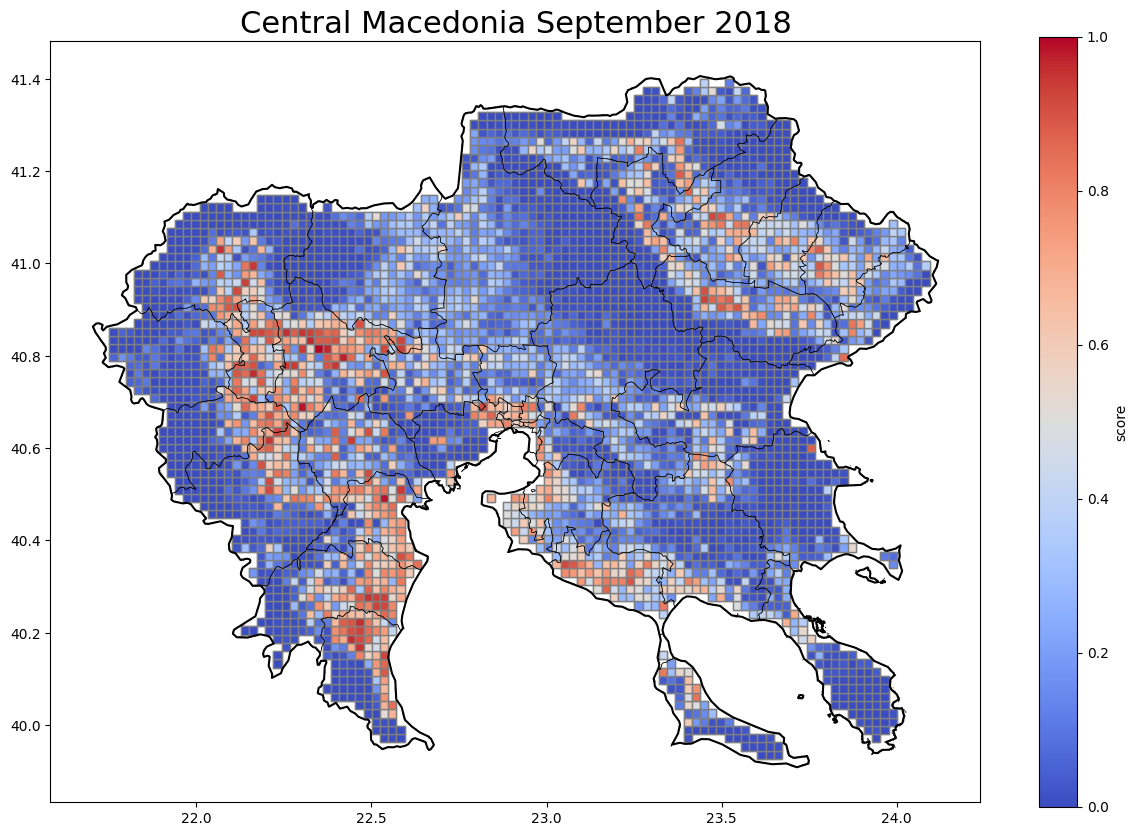

In [78]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2018_sep.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia September 2018', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()

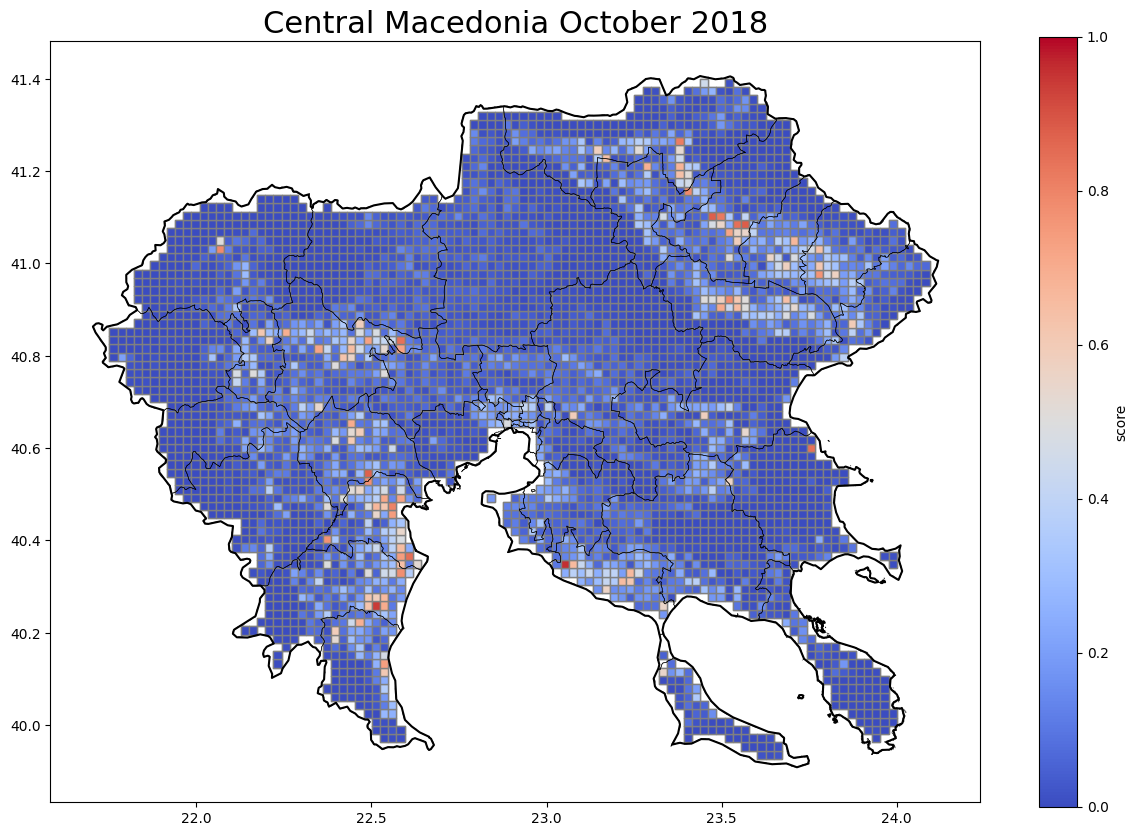

In [79]:
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the geometry column with the colors based on the float column
results_2018_oct.plot(ax=ax, column=float_column, cmap=cmap, edgecolor='grey')
greece_nuts2_gdf.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 1.5)
greece_lau1.plot(ax=ax, color='none', facecolor = 'none', edgecolor='black', linewidth = 0.4)

# Create colorbar
cbar = fig.colorbar(mapper, ax=ax)
cbar.set_label(float_column)

# Set title and labels
plt.title('Central Macedonia October 2018', size = 22)
# plt.xlabel('X-axis label')
# plt.ylabel('Y-axis label')

plt.show()